# Notebook 05 — Validación Externa del Protocolo sobre IEEE-CIS
**TFM:** Comparativa de modelos de aprendizaje automático supervisado para detección de fraude en tarjetas de crédito: resampling, interpretabilidad SHAP y validación externa sobre IEEE-CIS

**Prerrequisito:** Haber ejecutado notebooks 02 y 03. Los archivos `model_XGB_None.pkl` y `model_RF_SMOTE.pkl` deben existir en la carpeta `resultados/`.

**Dataset IEEE-CIS:**
- Coloca `train_transaction.csv` y `train_identity.csv` dentro de la carpeta `ieee_cis/`

**Librerías necesarias:**
```
pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn shap joblib matplotlib seaborn
```

**Descripción del experimento:**
Este notebook implementa dos escenarios complementarios:
- **Escenario A:** Validación del protocolo con configuración heredada de ULB (SMOTE, hiperparámetros base). Permite observar la caída de rendimiento al cambiar de dominio.
- **Escenario B:** Optimización específica para IEEE-CIS mediante GridSearchCV. Permite obtener el rendimiento real alcanzable en IEEE-CIS y diferenciar el comportamiento de XGBoost vs Random Forest en este dominio.


In [1]:
import pandas as pd
import psutil, os

print(f"RAM disponible: {psutil.virtual_memory().available / 1024**3:.1f} GB")

df_trans = pd.read_csv('ieee_cis/train_transaction.csv')
print(f"train_transaction cargado: {df_trans.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

df_identity = pd.read_csv('ieee_cis/train_identity.csv')
print(f"train_identity cargado: {df_identity.memory_usage(deep=True).sum() / 1024**2:.0f} MB")

RAM disponible: 56.2 GB
train_transaction cargado: 2062 MB
train_identity cargado: 143 MB


In [2]:
%pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn shap joblib matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ── IMPORTACIONES ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap, joblib, warnings, os, time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    average_precision_score, recall_score, f1_score,
    roc_auc_score, precision_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier

sns.set_style('whitegrid')
np.random.seed(42)
os.makedirs('resultados', exist_ok=True)

print('✅ Librerías cargadas correctamente')


✅ Librerías cargadas correctamente


## 1. Carga y preprocesamiento del dataset IEEE-CIS

In [4]:
# ── CARGA IEEE-CIS ─────────────────────────────────────────────────────────
print('Cargando dataset IEEE-CIS...')
df_trans    = pd.read_csv('ieee_cis/train_transaction.csv')
df_identity = pd.read_csv('ieee_cis/train_identity.csv')

df_ieee = df_trans.merge(df_identity, on='TransactionID', how='left')

print(f'Dimensiones      : {df_ieee.shape[0]:,} transacciones × {df_ieee.shape[1]} variables')
print(f'Fraudes          : {df_ieee["isFraud"].sum():,} ({df_ieee["isFraud"].mean()*100:.2f}%)')
print(f'Valores faltantes: {df_ieee.isnull().sum().sum():,}')


Cargando dataset IEEE-CIS...
Dimensiones      : 590,540 transacciones × 434 variables
Fraudes          : 20,663 (3.50%)
Valores faltantes: 115,523,073


In [5]:
# ── PREPROCESAMIENTO IEEE-CIS ───────────────────────────────────────────────
y_ieee = df_ieee['isFraud'].copy()
X_ieee = df_ieee.drop(['isFraud', 'TransactionID'], axis=1).copy()

# Codificar variables categóricas
cat_cols = X_ieee.select_dtypes(include=['object']).columns.tolist()
print(f'Variables categóricas encontradas: {len(cat_cols)}')
for col in cat_cols:
    le = LabelEncoder()
    X_ieee[col] = le.fit_transform(X_ieee[col].astype(str))

# Imputar valores faltantes con mediana
X_ieee = X_ieee.fillna(X_ieee.median(numeric_only=True))
print(f'Valores faltantes tras imputación: {X_ieee.isnull().sum().sum()}')

# Escalar TransactionAmt
if 'TransactionAmt' in X_ieee.columns:
    scaler_amt = StandardScaler()
    X_ieee['TransactionAmt'] = scaler_amt.fit_transform(X_ieee[['TransactionAmt']])

print(f'Dataset preprocesado: {X_ieee.shape}')
print(f'Ratio desbalance    : {int((y_ieee==0).sum() / (y_ieee==1).sum())}:1')


Variables categóricas encontradas: 31
Valores faltantes tras imputación: 0
Dataset preprocesado: (590540, 432)
Ratio desbalance    : 27:1


In [6]:
# ── DIVISIÓN ESTRATIFICADA 80/20 ───────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for tr_idx, te_idx in sss.split(X_ieee, y_ieee):
    X_train_ieee, X_test_ieee = X_ieee.iloc[tr_idx], X_ieee.iloc[te_idx]
    y_train_ieee, y_test_ieee = y_ieee.iloc[tr_idx], y_ieee.iloc[te_idx]

print(f'Train: {X_train_ieee.shape[0]:,} transacciones | Fraudes: {y_train_ieee.sum():,} ({y_train_ieee.mean()*100:.2f}%)')
print(f'Test : {X_test_ieee.shape[0]:,}  transacciones | Fraudes: {y_test_ieee.sum():,} ({y_test_ieee.mean()*100:.2f}%)')

ratio_ieee = int((y_train_ieee == 0).sum() / (y_train_ieee == 1).sum())
print(f'Ratio desbalance en train: {ratio_ieee}:1')


Train: 472,432 transacciones | Fraudes: 16,530 (3.50%)
Test : 118,108  transacciones | Fraudes: 4,133 (3.50%)
Ratio desbalance en train: 27:1


## 2. Escenario A — Validación del protocolo con configuración heredada de ULB

En este escenario se entrena XGBoost y Random Forest sobre IEEE-CIS usando la misma estrategia de resampling (SMOTE) y configuración base que se usó en ULB. El objetivo es medir la caída de rendimiento asociada al cambio de dominio, manteniendo constante el protocolo experimental.

**Nota metodológica:** Este escenario NO mide el rendimiento óptimo alcanzable en IEEE-CIS, sino la robustez del protocolo diseñado para ULB cuando se aplica a un dominio diferente sin ajuste específico.


In [7]:
# ── ESCENARIO A: Configuración heredada de ULB ─────────────────────────────
RANDOM_SEED = 42
smote = SMOTE(random_state=RANDOM_SEED)

# XGBoost: mismos hiperparámetros base que en ULB
xgb_A = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=ratio_ieee,
    tree_method='hist',
    eval_metric='aucpr',
    n_jobs=-1,
    random_state=RANDOM_SEED,
    verbosity=0
)

# Random Forest: mismos hiperparámetros base que en ULB
rf_A = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_SEED
)

models_A = {'XGB': xgb_A, 'RF': rf_A}
results_A = []

print('=== ESCENARIO A: Configuración heredada de ULB + SMOTE ===')
print()

for mname, model in models_A.items():
    print(f'▶ Entrenando {mname}...')
    pipe = ImbPipeline([('resampler', smote), ('classifier', model)])

    t0 = time.perf_counter()
    pipe.fit(X_train_ieee, y_train_ieee)
    t_train = time.perf_counter() - t0

    t1 = time.perf_counter()
    y_pred  = pipe.predict(X_test_ieee)
    t_infer = (time.perf_counter() - t1) / len(X_test_ieee) * 1000
    y_proba = pipe.predict_proba(X_test_ieee)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test_ieee, y_pred).ravel()

    res = {
        'Modelo'    : mname,
        'Escenario' : 'A_heredado',
        'Estrategia': 'SMOTE',
        'AUC_PR'    : round(average_precision_score(y_test_ieee, y_proba), 4),
        'AUC_ROC'   : round(roc_auc_score(y_test_ieee, y_proba), 4),
        'Recall'    : round(recall_score(y_test_ieee, y_pred), 4),
        'Precision' : round(precision_score(y_test_ieee, y_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_test_ieee, y_pred), 4),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'T_train_s' : round(t_train, 2),
        'T_inf_ms'  : round(t_infer, 4)
    }
    results_A.append(res)
    joblib.dump(pipe, f'resultados/model_{mname}_IEEE_A.pkl')

    print(f'   AUC-PR   : {res["AUC_PR"]}')
    print(f'   AUC-ROC  : {res["AUC_ROC"]}')
    print(f'   Recall   : {res["Recall"]}')
    print(f'   Precision: {res["Precision"]}')
    print(f'   F1       : {res["F1"]}')
    print(f'   TP={tp} | FP={fp} | TN={tn} | FN={fn}')
    print(f'   T_train  : {t_train:.1f}s | T_inf: {t_infer:.4f} ms/tx')
    print()

results_A_df = pd.DataFrame(results_A)
results_A_df.to_csv('resultados/tabla_ieee_escenario_A.csv', index=False)
print('✅ Escenario A completado y guardado.')


=== ESCENARIO A: Configuración heredada de ULB + SMOTE ===

▶ Entrenando XGB...
   AUC-PR   : 0.6138
   AUC-ROC  : 0.9268
   Recall   : 0.8309
   Precision: 0.1871
   F1       : 0.3055
   TP=3434 | FP=14915 | TN=99060 | FN=699
   T_train  : 44.9s | T_inf: 0.0005 ms/tx

▶ Entrenando RF...
   AUC-PR   : 0.6238
   AUC-ROC  : 0.9109
   Recall   : 0.4445
   Precision: 0.852
   F1       : 0.5842
   TP=1837 | FP=319 | TN=113656 | FN=2296
   T_train  : 80.8s | T_inf: 0.0042 ms/tx

✅ Escenario A completado y guardado.


## 3. Escenario B — Optimización específica para IEEE-CIS

En este escenario se aplica GridSearchCV con validación cruzada estratificada de 5 folds para encontrar los hiperparámetros óptimos de cada modelo específicamente para el dataset IEEE-CIS. Este escenario permite determinar el rendimiento real alcanzable en IEEE-CIS y comparar si el ranking de modelos (XGB vs RF) se mantiene respecto a ULB cuando ambos están correctamente optimizados.

**Nota:** Este escenario puede tardar entre 30 y 90 minutos dependiendo del hardware disponible.


In [8]:
# ── ESCENARIO B: GridSearchCV específico para IEEE-CIS (modo secuencial) ────
skf_ieee = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid reducido para evitar OOM — cubre los rangos más relevantes
param_grid_xgb = {
    'classifier__n_estimators' : [100, 200],
    'classifier__max_depth'    : [3, 6],
    'classifier__learning_rate': [0.1]
}

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth'   : [10, 20],
    'classifier__max_features': ['sqrt']
}

configs_B = {
    'XGB': (
        XGBClassifier(
            scale_pos_weight=ratio_ieee,
            tree_method='hist',
            eval_metric='aucpr',
            n_jobs=1,          # secuencial para evitar OOM
            random_state=42,
            verbosity=0
        ),
        param_grid_xgb
    ),
    'RF': (
        RandomForestClassifier(
            class_weight='balanced',
            n_jobs=1,          # secuencial para evitar OOM
            random_state=42
        ),
        param_grid_rf
    )
}

results_B = []
best_params_B = {}

print('=== ESCENARIO B: Optimización específica para IEEE-CIS ===')
print('(Modo secuencial — puede tardar 60-120 min dependiendo del hardware)')
print()

for mname, (model, param_grid) in configs_B.items():
    print(f'▶ GridSearchCV para {mname}...')
    smote_B = SMOTE(random_state=42)
    pipe_B  = ImbPipeline([('resampler', smote_B), ('classifier', model)])

    gs = GridSearchCV(
        pipe_B,
        param_grid,
        scoring='average_precision',
        cv=skf_ieee,
        n_jobs=1,              # CRÍTICO: secuencial para evitar OOM
        verbose=2
    )

    t0 = time.perf_counter()
    gs.fit(X_train_ieee, y_train_ieee)
    t_train = time.perf_counter() - t0

    best_params_B[mname] = gs.best_params_
    print(f'   Mejores hiperparámetros: {gs.best_params_}')
    print(f'   AUC-PR en validación   : {gs.best_score_:.4f}')

    t1 = time.perf_counter()
    y_pred  = gs.predict(X_test_ieee)
    t_infer = (time.perf_counter() - t1) / len(X_test_ieee) * 1000
    y_proba = gs.predict_proba(X_test_ieee)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test_ieee, y_pred).ravel()

    res = {
        'Modelo'    : mname,
        'Escenario' : 'B_optimizado',
        'Estrategia': 'SMOTE+GridSearchCV',
        'AUC_PR'    : round(average_precision_score(y_test_ieee, y_proba), 4),
        'AUC_ROC'   : round(roc_auc_score(y_test_ieee, y_proba), 4),
        'Recall'    : round(recall_score(y_test_ieee, y_pred), 4),
        'Precision' : round(precision_score(y_test_ieee, y_pred, zero_division=0), 4),
        'F1'        : round(f1_score(y_test_ieee, y_pred), 4),
        'TP': int(tp), 'FP': int(fp), 'TN': int(tn), 'FN': int(fn),
        'T_train_s' : round(t_train, 2),
        'T_inf_ms'  : round(t_infer, 4),
        'Best_params': str(gs.best_params_)
    }
    results_B.append(res)
    joblib.dump(gs.best_estimator_, f'resultados/model_{mname}_IEEE_B.pkl')

    print(f'   AUC-PR (test) : {res["AUC_PR"]}')
    print(f'   AUC-ROC       : {res["AUC_ROC"]}')
    print(f'   Recall        : {res["Recall"]}')
    print(f'   Precision     : {res["Precision"]}')
    print(f'   F1            : {res["F1"]}')
    print(f'   TP={tp} | FP={fp} | TN={tn} | FN={fn}')
    print(f'   T_train       : {t_train:.1f}s')
    print()

results_B_df = pd.DataFrame(results_B)
results_B_df.to_csv('resultados/tabla_ieee_escenario_B.csv', index=False)
print('✅ Escenario B completado y guardado.')

=== ESCENARIO B: Optimización específica para IEEE-CIS ===
(Modo secuencial — puede tardar 60-120 min dependiendo del hardware)

▶ GridSearchCV para XGB...
Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time= 2.2min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time= 1.6min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time= 1.5min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time= 1.6min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=100; total time= 1.5min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=200; total time= 2.5min
[CV] END classifier__learning_rate=0.1, classifier__max_depth=3, classifier__n_estimators=200; total

## 4. Tabla comparativa completa ULB vs IEEE-CIS

In [10]:
import pandas as pd

results_ulb = pd.read_csv('resultados/tabla_resultados_ulb.csv')
print("Columnas:", results_ulb.columns.tolist())
print()
print("Valores únicos en 'Modelo':", results_ulb['Modelo'].unique() if 'Modelo' in results_ulb.columns else "COLUMNA NO EXISTE")
print("Valores únicos en 'Estrategia':", results_ulb['Estrategia'].unique() if 'Estrategia' in results_ulb.columns else "COLUMNA NO EXISTE")
print()
print(results_ulb.head())

Columnas: ['Modelo', 'Estrategia', 'AUC_PR', 'AUC_ROC', 'Recall', 'Precision', 'F1', 'TP', 'FP', 'TN', 'FN', 'T_train_s', 'T_infer_ms_tx', 'Best_params', 'CV_AUC_PR_mean']

Valores únicos en 'Modelo': <StringArray>
['LR', 'DT', 'RF', 'XGB', 'LGBM']
Length: 5, dtype: str
Valores únicos en 'Estrategia': <StringArray>
[nan, 'SMOTE', 'ADASYN']
Length: 3, dtype: str

  Modelo Estrategia  AUC_PR  AUC_ROC  Recall  Precision      F1  TP    FP  \
0     LR        NaN  0.7189   0.9722  0.9184     0.0609  0.1141  90  1389   
1     LR      SMOTE  0.7237   0.9699  0.9184     0.0581  0.1094  90  1458   
2     LR     ADASYN  0.7316   0.9725  0.9184     0.0181  0.0355  90  4886   
3     DT        NaN  0.6119   0.8671  0.7347     0.6102  0.6667  72    46   
4     DT      SMOTE  0.4512   0.8850  0.8265     0.0530  0.0997  81  1446   

      TN  FN  T_train_s  T_infer_ms_tx  \
0  55475   8      3.727        0.00012   
1  55406   8      5.214        0.00028   
2  51978   8      5.843        0.00012   
3  5

In [11]:
# ── TABLA COMPARATIVA COMPLETA ─────────────────────────────────────────────
results_ulb = pd.read_csv('resultados/tabla_resultados_ulb.csv')

# "Sin tratamiento" se guardó como NaN en el CSV — filtrar correctamente
xgb_ulb = results_ulb[
    (results_ulb['Modelo'] == 'XGB') & (results_ulb['Estrategia'].isna())
].iloc[0]

rf_ulb = results_ulb[
    (results_ulb['Modelo'] == 'RF') & (results_ulb['Estrategia'] == 'SMOTE')
].iloc[0]

# Renombrar métrica de inferencia para que coincida con los resultados IEEE-CIS
xgb_ulb = xgb_ulb.rename({'T_infer_ms_tx': 'T_inf_ms'})
rf_ulb  = rf_ulb.rename({'T_infer_ms_tx': 'T_inf_ms'})

print('=' * 75)
print('TABLA COMPARATIVA: ULB (entrenamiento) vs IEEE-CIS (validación externa)')
print('=' * 75)
print()

header = f"{'Modelo':<6} {'Dataset':<12} {'Escenario':<14} {'AUC-PR':>8} {'AUC-ROC':>8} {'Recall':>8} {'Precision':>10} {'F1':>8}"
print(header)
print('-' * 75)

# ULB
print(f"{'XGB':<6} {'ULB':<12} {'Finalista':<14} {xgb_ulb['AUC_PR']:>8.4f} {xgb_ulb['AUC_ROC']:>8.4f} {xgb_ulb['Recall']:>8.4f} {xgb_ulb['Precision']:>10.4f} {xgb_ulb['F1']:>8.4f}")
print(f"{'RF':<6}  {'ULB':<12} {'Finalista':<14} {rf_ulb['AUC_PR']:>8.4f}  {rf_ulb['AUC_ROC']:>8.4f} {rf_ulb['Recall']:>8.4f} {rf_ulb['Precision']:>10.4f} {rf_ulb['F1']:>8.4f}")

print('-' * 75)

# Escenario A
for _, row in results_A_df.iterrows():
    delta = row['AUC_PR'] - (xgb_ulb['AUC_PR'] if row['Modelo'] == 'XGB' else rf_ulb['AUC_PR'])
    print(f"{row['Modelo']:<6} {'IEEE-CIS':<12} {'A_heredado':<14} {row['AUC_PR']:>8.4f} {row['AUC_ROC']:>8.4f} {row['Recall']:>8.4f} {row['Precision']:>10.4f} {row['F1']:>8.4f}  Δ={delta:+.4f}")

print('-' * 75)

# Escenario B
for _, row in results_B_df.iterrows():
    delta  = row['AUC_PR'] - (xgb_ulb['AUC_PR'] if row['Modelo'] == 'XGB' else rf_ulb['AUC_PR'])
    mejora = row['AUC_PR'] - results_A_df[results_A_df['Modelo'] == row['Modelo']]['AUC_PR'].values[0]
    print(f"{row['Modelo']:<6} {'IEEE-CIS':<12} {'B_optimizado':<14} {row['AUC_PR']:>8.4f} {row['AUC_ROC']:>8.4f} {row['Recall']:>8.4f} {row['Precision']:>10.4f} {row['F1']:>8.4f}  Δ={delta:+.4f} mejora_vs_A={mejora:+.4f}")

print('=' * 75)
print()
print('Δ = diferencia de AUC-PR respecto a ULB (negativo indica caída)')

TABLA COMPARATIVA: ULB (entrenamiento) vs IEEE-CIS (validación externa)

Modelo Dataset      Escenario        AUC-PR  AUC-ROC   Recall  Precision       F1
---------------------------------------------------------------------------
XGB    ULB          Finalista        0.8830   0.9601   0.8367     0.8817   0.8586
RF      ULB          Finalista        0.8756    0.9673   0.8367     0.8542   0.8454
---------------------------------------------------------------------------
XGB    IEEE-CIS     A_heredado       0.6138   0.9268   0.8309     0.1871   0.3055  Δ=-0.2692
RF     IEEE-CIS     A_heredado       0.6238   0.9109   0.4445     0.8520   0.5842  Δ=-0.2518
---------------------------------------------------------------------------
XGB    IEEE-CIS     B_optimizado     0.6138   0.9268   0.8309     0.1871   0.3055  Δ=-0.2692 mejora_vs_A=+0.0000
RF     IEEE-CIS     B_optimizado     0.6238   0.9109   0.4445     0.8520   0.5842  Δ=-0.2518 mejora_vs_A=+0.0000

Δ = diferencia de AUC-PR respecto a UL

## 5. Visualizaciones

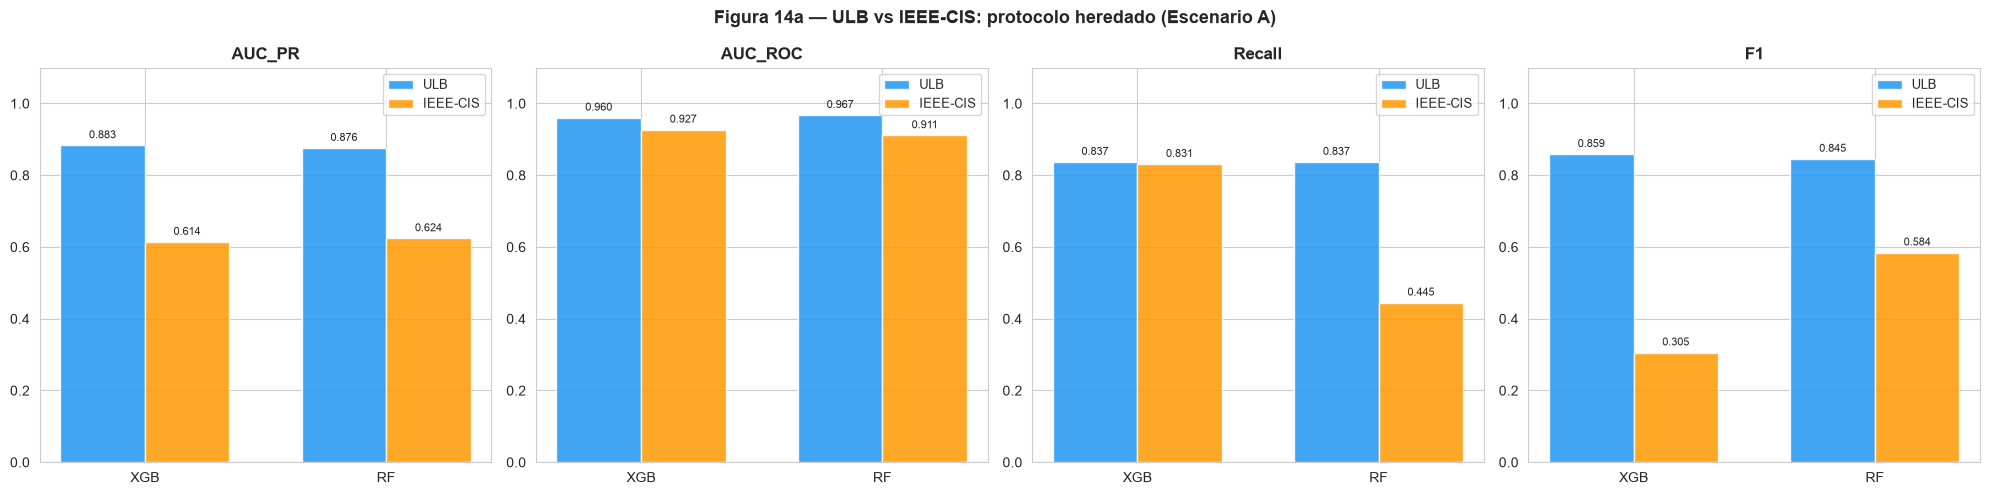

✅ fig14a guardada


In [12]:
# ── FIGURA 14a: Comparativa Escenario A (ULB vs IEEE-CIS heredado) ─────────
metrics_vis = ['AUC_PR', 'AUC_ROC', 'Recall', 'F1']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, metric in enumerate(metrics_vis):
    ulb_vals  = [xgb_ulb[metric], rf_ulb[metric]]
    ieee_vals = [
        results_A_df[results_A_df['Modelo']=='XGB'][metric].values[0],
        results_A_df[results_A_df['Modelo']=='RF'][metric].values[0]
    ]
    labels = ['XGB', 'RF']
    x = np.arange(len(labels))
    w = 0.35

    axes[i].bar(x - w/2, ulb_vals,  w, label='ULB',     color='#2196F3', alpha=0.85)
    axes[i].bar(x + w/2, ieee_vals, w, label='IEEE-CIS', color='#FF9800', alpha=0.85)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(labels)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].legend(fontsize=9)
    for j in range(len(labels)):
        axes[i].text(j - w/2, ulb_vals[j]  + 0.02, f'{ulb_vals[j]:.3f}',  ha='center', fontsize=8)
        axes[i].text(j + w/2, ieee_vals[j] + 0.02, f'{ieee_vals[j]:.3f}', ha='center', fontsize=8)

plt.suptitle('Figura 14a — ULB vs IEEE-CIS: protocolo heredado (Escenario A)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/fig14a_comparativa_escenario_A.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ fig14a guardada')


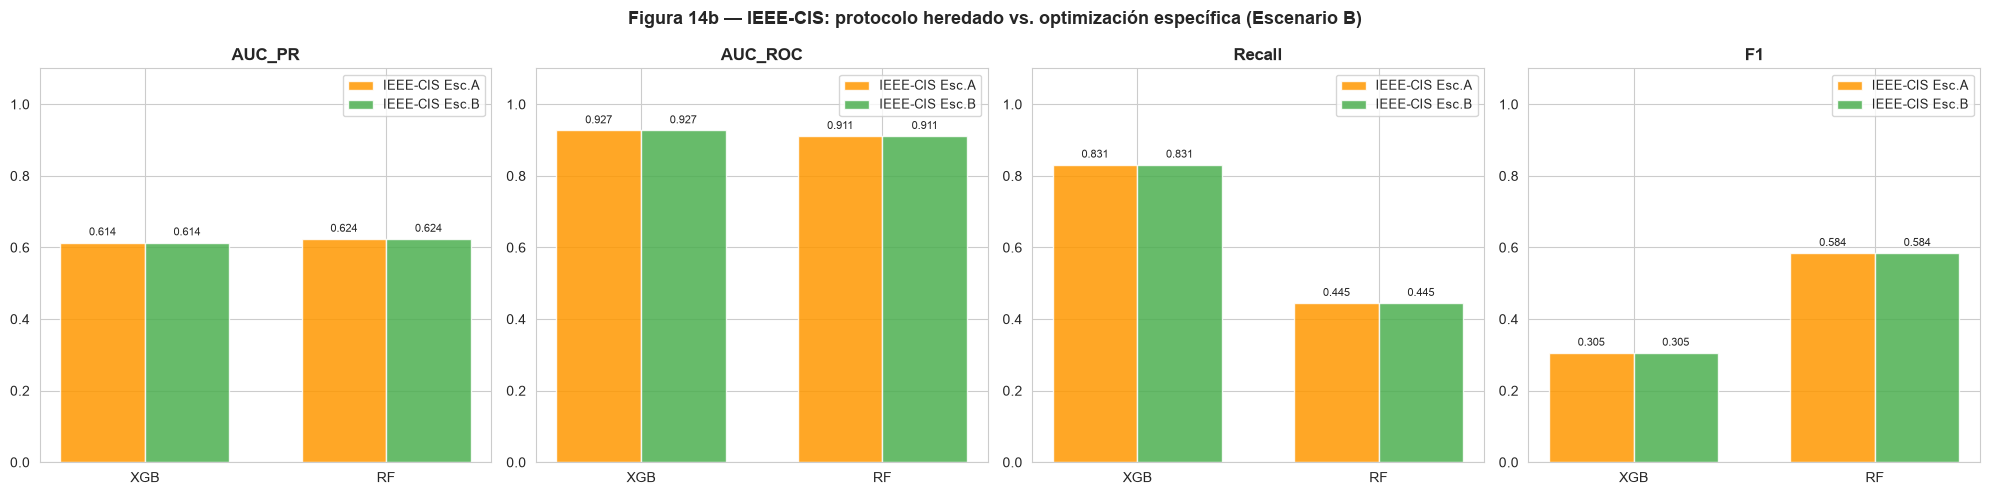

✅ fig14b guardada


In [13]:
# ── FIGURA 14b: Comparativa Escenario B (IEEE-CIS optimizado) ──────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, metric in enumerate(metrics_vis):
    ieee_A_vals = [
        results_A_df[results_A_df['Modelo']=='XGB'][metric].values[0],
        results_A_df[results_A_df['Modelo']=='RF'][metric].values[0]
    ]
    ieee_B_vals = [
        results_B_df[results_B_df['Modelo']=='XGB'][metric].values[0],
        results_B_df[results_B_df['Modelo']=='RF'][metric].values[0]
    ]
    labels = ['XGB', 'RF']
    x = np.arange(len(labels))
    w = 0.35

    axes[i].bar(x - w/2, ieee_A_vals, w, label='IEEE-CIS Esc.A', color='#FF9800', alpha=0.85)
    axes[i].bar(x + w/2, ieee_B_vals, w, label='IEEE-CIS Esc.B', color='#4CAF50', alpha=0.85)
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(labels)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].legend(fontsize=9)
    for j in range(len(labels)):
        axes[i].text(j - w/2, ieee_A_vals[j] + 0.02, f'{ieee_A_vals[j]:.3f}', ha='center', fontsize=8)
        axes[i].text(j + w/2, ieee_B_vals[j] + 0.02, f'{ieee_B_vals[j]:.3f}', ha='center', fontsize=8)

plt.suptitle('Figura 14b — IEEE-CIS: protocolo heredado vs. optimización específica (Escenario B)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/fig14b_comparativa_escenario_B.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ fig14b guardada')


### Figura 12 (versión final, usada en el TFM)

El tutor indicó que la Figura 12 original (una sola fila con 4 métricas y barras agrupadas) resultaba difícil de leer. Se reorganiza en un array de 2 filas (una por modelo) x 4 columnas (una por métrica), manteniendo los mismos datos.

In [ ]:
# ── FIGURA 12 (revisada): comparación ULB vs IEEE-CIS en dos filas ─────────
metrics_vis = ['AUC_PR', 'AUC_ROC', 'Recall', 'F1']
model_data = {
    'XGB': {'ULB': xgb_ulb, 'IEEE-CIS': results_A_df[results_A_df['Modelo']=='XGB'].iloc[0]},
    'RF':  {'ULB': rf_ulb,  'IEEE-CIS': results_A_df[results_A_df['Modelo']=='RF'].iloc[0]},
}

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=True)
colors = {'ULB': '#1f77b4', 'IEEE-CIS': '#ff7f0e'}

for row, model in enumerate(['XGB', 'RF']):
    for col, metric in enumerate(metrics_vis):
        ax = axes[row, col]
        vals = [model_data[model]['ULB'][metric], model_data[model]['IEEE-CIS'][metric]]
        bars = ax.bar(['ULB', 'IEEE-CIS'], vals, color=[colors['ULB'], colors['IEEE-CIS']])
        ax.set_ylim(0, 1.05)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)
        if row == 0:
            ax.set_title(metric, fontsize=12, fontweight='bold')
        if col == 0:
            ax.set_ylabel(model, fontsize=12, fontweight='bold')
        ax.tick_params(labelsize=9)

fig.suptitle('Figura 12 — Comparación de métricas entre ULB e IEEE-CIS', fontsize=14, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig('resultados/fig12_comparativa_2filas.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ fig12_comparativa_2filas guardada (versión final usada en el TFM)')


## 6. Resumen final

In [14]:
# ── RESUMEN EJECUTIVO ──────────────────────────────────────────────────────
print('=' * 65)
print('RESUMEN — Validación externa del protocolo sobre IEEE-CIS')
print('=' * 65)
print()
print('Dataset origen  : ULB Credit Card Fraud Detection (2013)')
print('Dataset destino : IEEE-CIS Fraud Detection (2019)')
print()
print('--- Escenario A: Protocolo heredado de ULB ---')
for _, row in results_A_df.iterrows():
    ulb_pr = xgb_ulb['AUC_PR'] if row['Modelo']=='XGB' else rf_ulb['AUC_PR']
    caida  = row['AUC_PR'] - ulb_pr
    print(f"  {row['Modelo']}: AUC-PR ULB={ulb_pr:.4f} → IEEE-CIS={row['AUC_PR']:.4f} (Δ={caida:+.4f})")

print()
print('--- Escenario B: Optimización específica para IEEE-CIS ---')
for _, row in results_B_df.iterrows():
    ulb_pr = xgb_ulb['AUC_PR'] if row['Modelo']=='XGB' else rf_ulb['AUC_PR']
    caida  = row['AUC_PR'] - ulb_pr
    mejora = row['AUC_PR'] - results_A_df[results_A_df['Modelo']==row['Modelo']]['AUC_PR'].values[0]
    print(f"  {row['Modelo']}: AUC-PR IEEE-CIS={row['AUC_PR']:.4f} (Δ_ULB={caida:+.4f} | mejora_vs_A={mejora:+.4f})")
    print(f"         Mejores params: {row['Best_params']}")

print()
print('Archivos generados en resultados/:')
archivos = [
    'tabla_ieee_escenario_A.csv',
    'tabla_ieee_escenario_B.csv',
    'fig14a_comparativa_escenario_A.png',
    'fig14b_comparativa_escenario_B.png',
    'model_XGB_IEEE_A.pkl', 'model_RF_IEEE_A.pkl',
    'model_XGB_IEEE_B.pkl', 'model_RF_IEEE_B.pkl'
]
for f in archivos:
    print(f'  ✅ {f}')
print()
print('✅ Validación externa completada.')
print('➡️  Comparte los CSV y el resumen impreso para incorporar al TFM.')


RESUMEN — Validación externa del protocolo sobre IEEE-CIS

Dataset origen  : ULB Credit Card Fraud Detection (2013)
Dataset destino : IEEE-CIS Fraud Detection (2019)

--- Escenario A: Protocolo heredado de ULB ---
  XGB: AUC-PR ULB=0.8830 → IEEE-CIS=0.6138 (Δ=-0.2692)
  RF: AUC-PR ULB=0.8756 → IEEE-CIS=0.6238 (Δ=-0.2518)

--- Escenario B: Optimización específica para IEEE-CIS ---
  XGB: AUC-PR IEEE-CIS=0.6138 (Δ_ULB=-0.2692 | mejora_vs_A=+0.0000)
         Mejores params: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 6, 'classifier__n_estimators': 200}
  RF: AUC-PR IEEE-CIS=0.6238 (Δ_ULB=-0.2518 | mejora_vs_A=+0.0000)
         Mejores params: {'classifier__max_depth': 20, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}

Archivos generados en resultados/:
  ✅ tabla_ieee_escenario_A.csv
  ✅ tabla_ieee_escenario_B.csv
  ✅ fig14a_comparativa_escenario_A.png
  ✅ fig14b_comparativa_escenario_B.png
  ✅ model_XGB_IEEE_A.pkl
  ✅ model_RF_IEEE_A.pkl
  ✅ model_XG